BITS ID: 2025AG05481

Name: JESWIN SANTOSH

Email: 2025ag05481@wilp.bits-pilani.ac.in

Date: 20-04-2026

## Dataset

> Food-101
>
> [https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/](https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/)

---

# Custom CNN architecture using PyTorch

In [22]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import time
import json
import os

# Deep learning
import torch
# For image processing
from PIL import Image
import cv2

## 1.1 Dataset Selection and Loading

### Loading Dataset

In [23]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Standard ImageNet normalization values
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
# Define the transformations
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),       # 1. Consistent Size
    transforms.ToTensor(),                # Converts to [0, 1] range
    transforms.Normalize(mean, std)       # 2. Normalize Pixel Values
])

data_dir = 'dataset/food-101/images'

# Load the dataset
dataset = datasets.ImageFolder(root=data_dir, transform=data_transforms)

# Check the classes found
print(f"Number of Classes: {len(dataset.classes)}")
print(f"Total images: {len(dataset)}")

Number of Classes: 101
Total images: 101000


### Metadata

In [24]:
dataset_name = "Food-101"
dataset_source = "https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/"
n_samples = 101000
n_classes = 101
samples_per_class = "min: 1000, max: 1000, avg: 1000"
image_shape = [224, 224, 3]
problem_type = "classification"

# Primary metric selection
primary_metric = "TODO: accuracy OR precision OR recall"
metric_justification = """
TODO: Write 1-2 sentences explaining your metric choice.
"""

print("\n" + "="*70)
print("DATASET INFORMATION")
print("\nDATASET INFORMATION")
print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Total Samples: {n_samples}")
print(f"Number of Classes: {n_classes}")
print(f"Samples per Class: {samples_per_class}")
print(f"Image Shape: {image_shape}")
print(f"Primary Metric: {primary_metric}")
print(f"Metric Justification: {metric_justification}")


DATASET INFORMATION

DATASET INFORMATION
Dataset: Food-101
Source: https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/
Total Samples: 101000
Number of Classes: 101
Samples per Class: min: 1000, max: 1000, avg: 1000
Image Shape: [224, 224, 3]
Primary Metric: TODO: accuracy OR precision OR recall
Metric Justification: 
TODO: Write 1-2 sentences explaining your metric choice.



---

## 1.2 Data Exploration and Visualization

In [25]:
import math

def show_samples_multiline(dataset, cols=5):
    classes = dataset.classes
    rows = math.ceil(len(classes) / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = axes.flatten() # Flatten to easily loop over

    for i, class_name in enumerate(classes):
        # Get first image of this class
        idx = dataset.targets.index(i)
        img, _ = dataset[idx]

        # Unnormalize
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(np.array([0.229, 0.224, 0.225]) * img + np.array([0.485, 0.456, 0.406]), 0, 1)

        axes[i].imshow(img)
        axes[i].set_title(class_name, fontsize=10)
        axes[i].axis('off')

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

show_samples_multiline(dataset, cols=5)

Output hidden; open in https://colab.research.google.com to view.

,Class Name,Image Count
0,apple_pie,1000
1,baby_back_ribs,1000
2,baklava,1000
3,beef_carpaccio,1000
4,beef_tartare,1000


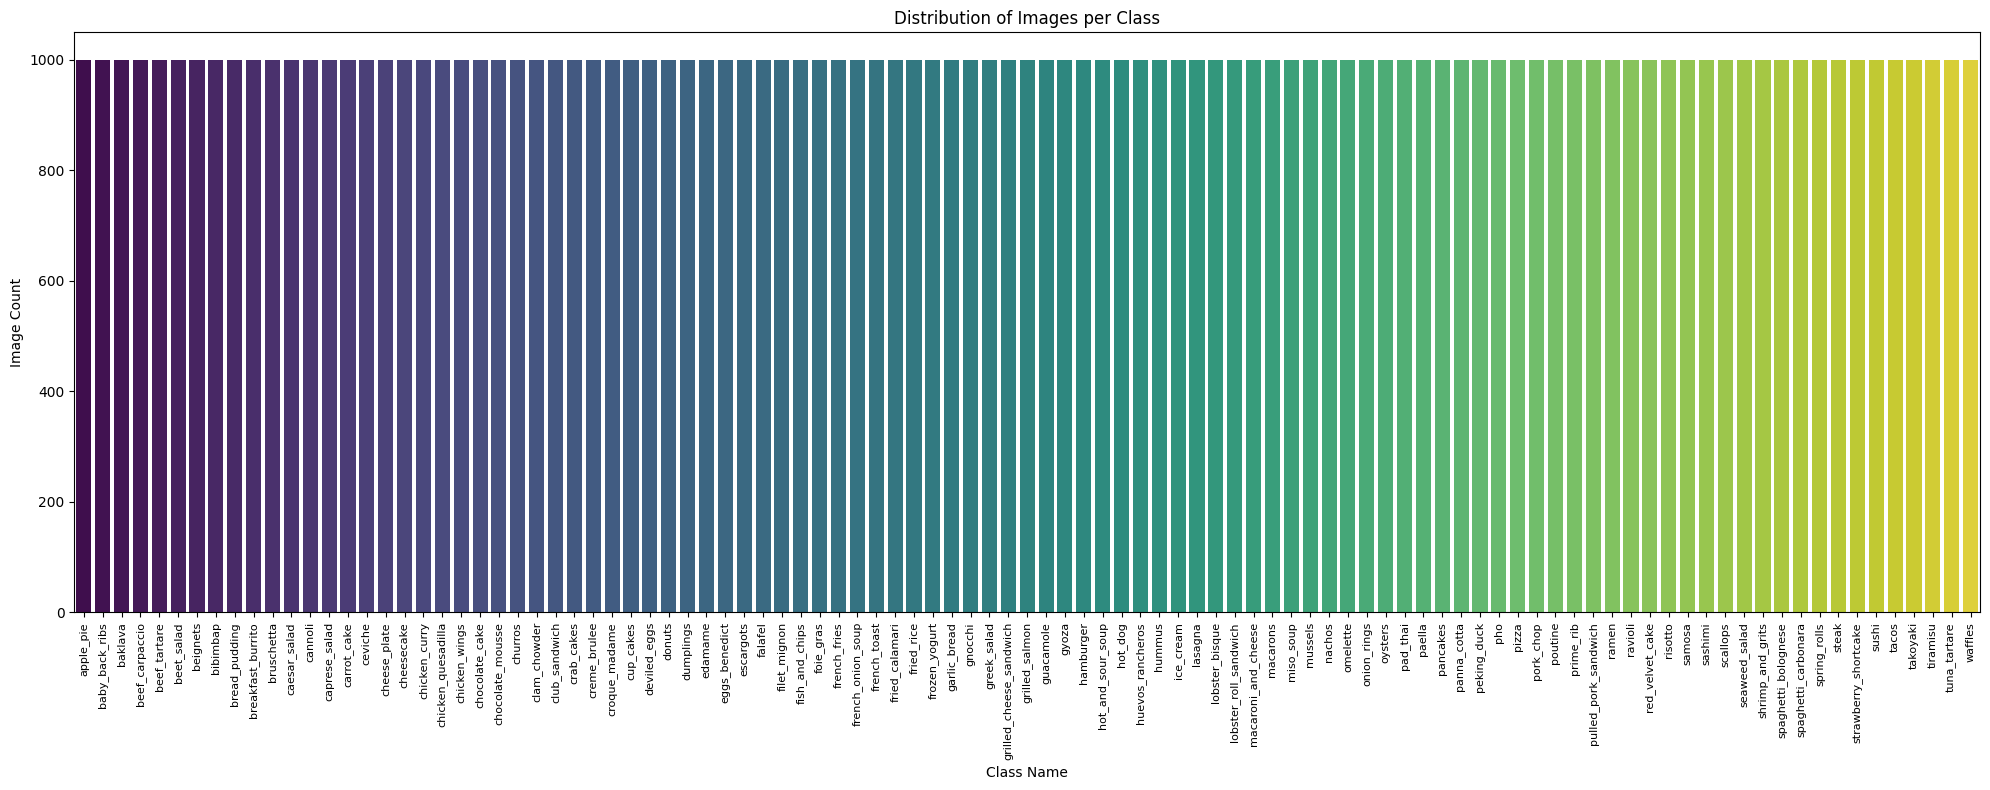

In [26]:
from collections import Counter

# count of images per class
counts = Counter(dataset.targets)

df_data = [
    {"Class Name": dataset.classes[i], "Image Count": counts[i]}
    for i in range(len(dataset.classes))
]

df = pd.DataFrame(df_data)
display(df.head())

plt.figure(figsize=(20, 8))
sns.barplot(
    x="Class Name",
    y="Image Count",
    data=df,
    hue="Class Name",
    palette="viridis",
    legend=False
)

plt.xticks(rotation=90, ha='center', fontsize=8)

plt.title("Distribution of Images per Class")
plt.tight_layout()
plt.show()

In [27]:
# Basic Statistics
print(f"Number of classes: {len(dataset.classes)}")
print(f"Total number of images: {len(dataset)}")

# Get dimensions of the first image
img, label = dataset[0]
print(f"Image shape (C, H, W): {img.shape}")
print(f"Label index: {label} (Class: {dataset.classes[label]})")

# Calculate Mean and Std of the actual loaded pixels (optional but useful)
# Note: This is done on a single batch for speed
loader = DataLoader(dataset, batch_size=64, shuffle=True)
data_iter = iter(loader)
images, _ = next(data_iter)

print(f"Batch Mean: {images.mean(dim=[0, 2, 3])}")
print(f"Batch Std: {images.std(dim=[0, 2, 3])}")

Number of classes: 101
Total number of images: 101000
Image shape (C, H, W): torch.Size([3, 224, 224])
Label index: 0 (Class: apple_pie)
Batch Mean: tensor([ 0.2564, -0.0875, -0.3053])
Batch Std: tensor([1.1609, 1.2119, 1.2015])


---

# 1.3 Data Preprocessing

In [28]:
import torch
from torchvision import datasets
from torch.utils.data import random_split

# (90% Train, 10% Test)
train_size = int(0.9 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42) # For reproducible results
)

# ------------------------------------------

train_test_ratio = "90/10"
train_samples = len(train_dataset)
test_samples = len(test_dataset)

print(f"\nTrain/Test Split: {train_test_ratio}")
print(f"Training Samples: {train_samples}")
print(f"Test Samples: {test_samples}")


Train/Test Split: 90/10
Training Samples: 90900
Test Samples: 10100


---

# 2.1 Custom CNN Architecture Design

In [29]:
import torch.nn as nn
import torch.optim as optim
import time

class FoodCNN(nn.Module):
    def __init__(self, n_classes):
        super(FoodCNN, self).__init__()

        # Feature Extraction
        self.features = nn.Sequential(
            # Layer 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # Output: 32 x 112 x 112

            # Layer 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # Output: 64 x 56 x 56

            # Layer 3 (Optional extra depth for better accuracy)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # Output: 128 x 28 x 28
        )

        # Global Average Pooling
        # Instead of Flattening (128*28*28), we take the average of each 28x28 map.
        # This results in a vector of size 128.
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Output Layer (Dense/Linear)
        # Input size is 128 (from the 128 feature maps)
        self.classifier = nn.Linear(128, n_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        x = torch.flatten(x, 1) # Flattens the 1x1 dimensions, leaving the 128 features
        x = self.classifier(x)
        return x

def build_custom_cnn(n_classes):
    model = FoodCNN(n_classes)
    return model

# Create model instance
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_classes = len(dataset.classes)
custom_cnn = build_custom_cnn(n_classes).to(device)

In [30]:
from torchsummary import summary

# Convert the torch.device object to its string representation for the summary function
summary(custom_cnn, input_size=(3, 224, 224), device=str(device))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 224, 224]             896
              ReLU-2         [-1, 32, 224, 224]               0
         MaxPool2d-3         [-1, 32, 112, 112]               0
            Conv2d-4         [-1, 64, 112, 112]          18,496
              ReLU-5         [-1, 64, 112, 112]               0
         MaxPool2d-6           [-1, 64, 56, 56]               0
            Conv2d-7          [-1, 128, 56, 56]          73,856
              ReLU-8          [-1, 128, 56, 56]               0
         MaxPool2d-9          [-1, 128, 28, 28]               0
AdaptiveAvgPool2d-10            [-1, 128, 1, 1]               0
           Linear-11                  [-1, 101]          13,029
Total params: 106,277
Trainable params: 106,277
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.57
Forward/

### Compile

In [31]:
# Configuration (Loss and Optimizer)
criterion = nn.CrossEntropyLoss() # Includes LogSoftmax internally for multi-class
optimizer = optim.Adam(custom_cnn.parameters(), lr=0.001)

---

# 2.2 Train Custom CNN

In [32]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

# train_loader: Shuffles data so the model doesn't learn the order of images
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2  # Number of CPU cores to use for loading images
)

# test_loader
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print(f"DataLoaders created with batch size: {BATCH_SIZE}")

DataLoaders created with batch size: 32


In [33]:
import time

print("\n" + "="*70)
print("CUSTOM CNN TRAINING")

# Track training time
custom_cnn_start_time = time.time()

# Training Configuration
epochs = 10
custom_cnn.train()
losses = []

print(f"\nStarting Training on {device}...")
print(f"Total Epochs: {epochs}")
print(f"Batches per Epoch: {len(train_loader)}")

for epoch in range(epochs):
    running_loss = 0.0
    epoch_start_time = time.time()

    for i, (inputs, labels) in enumerate(train_loader):
        # Move data to the same device as model
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = custom_cnn(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Capture initial loss
        if epoch == 0 and i == 0:
            custom_cnn_initial_loss = loss.item()
            print(f" -> Initial Batch Loss recorded: {custom_cnn_initial_loss:.4f}")

        running_loss += loss.item()

        # Print progress every 50 batches
        if (i + 1) % 50 == 0:
            percent_complete = 100 * (i + 1) / len(train_loader)
            print(f"   Epoch [{epoch+1}/{epochs}] | Batch [{i+1}/{len(train_loader)}] | Progress: {percent_complete:.1f}% | Current Loss: {loss.item():.4f}")

    # End of Epoch Stats
    epoch_loss = running_loss / len(train_loader)
    losses.append(epoch_loss)
    epoch_duration = time.time() - epoch_start_time

    print(f"\n>>> [EPOCH {epoch+1} FINISHED]")
    print(f"    Average Loss: {epoch_loss:.4f}")
    print(f"    Time taken: {epoch_duration:.2f}s")
    print("-" * 30)

# Finalize Metrics
custom_cnn_training_time = time.time() - custom_cnn_start_time
custom_cnn_final_loss = losses[-1]

print("\n" + "="*70)
print("TRAINING PROCESS COMPLETE")
print(f"Total Duration: {custom_cnn_training_time/60:.2f} minutes")
print(f"Initial Loss: {custom_cnn_initial_loss:.4f}")
print(f"Final Loss: {custom_cnn_final_loss:.4f}")
print("="*70)


CUSTOM CNN TRAINING

Starting Training on cuda...
Total Epochs: 10
Batches per Epoch: 2841
 -> Initial Batch Loss recorded: 4.6248
   Epoch [1/10] | Batch [50/2841] | Progress: 1.8% | Current Loss: 4.6227
   Epoch [1/10] | Batch [100/2841] | Progress: 3.5% | Current Loss: 4.6104
   Epoch [1/10] | Batch [150/2841] | Progress: 5.3% | Current Loss: 4.5894
   Epoch [1/10] | Batch [200/2841] | Progress: 7.0% | Current Loss: 4.5755
   Epoch [1/10] | Batch [250/2841] | Progress: 8.8% | Current Loss: 4.4993
   Epoch [1/10] | Batch [300/2841] | Progress: 10.6% | Current Loss: 4.3924
   Epoch [1/10] | Batch [350/2841] | Progress: 12.3% | Current Loss: 4.4484
   Epoch [1/10] | Batch [400/2841] | Progress: 14.1% | Current Loss: 4.4736
   Epoch [1/10] | Batch [450/2841] | Progress: 15.8% | Current Loss: 4.4611
   Epoch [1/10] | Batch [500/2841] | Progress: 17.6% | Current Loss: 4.4663
   Epoch [1/10] | Batch [550/2841] | Progress: 19.4% | Current Loss: 4.2876
   Epoch [1/10] | Batch [600/2841] | P

In [34]:
import os

def save_model(model, file_path="custom_cnn.pth"):
    os.makedirs(os.path.dirname(file_path) if os.path.dirname(file_path) else '.', exist_ok=True)

    torch.save(model.state_dict(), file_path)
    print(f"Model saved successfully to {file_path}")

def load_model(model_class, n_classes, file_path="custom_cnn.pth", device="cpu"):
    """
    Instantiates the model and loads weights from the specified file.
    """
    # Instantiate the model architecture
    model = model_class(n_classes)

    # Load the state dictionary
    state_dict = torch.load(file_path, map_location=torch.device(device))

    # Load weights into the model
    model.load_state_dict(state_dict)

    # Move to device and set to evaluation mode
    model.to(device)
    model.eval()

    print(f"Model loaded successfully from {file_path}")
    return model


save_model(custom_cnn, "food101_model.pth")

# loaded_model = load_model(
#    model_class=FoodCNN,
#    n_classes=len(dataset.classes),
#    file_path="food101_model.pth",
#    device=device
#)

Model saved successfully to food101_model.pth


---

# 2.3 Evaluate Custom CNN

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("\nCUSTOM CNN EVALUATION")

# Set model to evaluation mode
custom_cnn.eval()

y_true = []
y_pred = []

# Disable gradient calculation for evaluation (saves memory and time)
print("Gathering predictions from test set...")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)

        # Forward pass
        outputs = custom_cnn(inputs)

        # Get the index of the highest score (the prediction)
        _, predicted = torch.max(outputs, 1)

        # Move back to CPU and convert to numpy for sklearn
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

custom_cnn_accuracy = accuracy_score(y_true, y_pred)
custom_cnn_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
custom_cnn_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
custom_cnn_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

print("\nCustom CNN Performance:")
print(f"Accuracy:  {custom_cnn_accuracy:.4f}")
print(f"Precision: {custom_cnn_precision:.4f}")
print(f"Recall:    {custom_cnn_recall:.4f}")
print(f"F1-Score:  {custom_cnn_f1:.4f}")


CUSTOM CNN EVALUATION
Gathering predictions from test set...

Custom CNN Performance:
Accuracy:  0.2949
Precision: 0.3425
Recall:    0.2981
F1-Score:  0.2868


---

# 2.4 Visualize Custom CNN Results

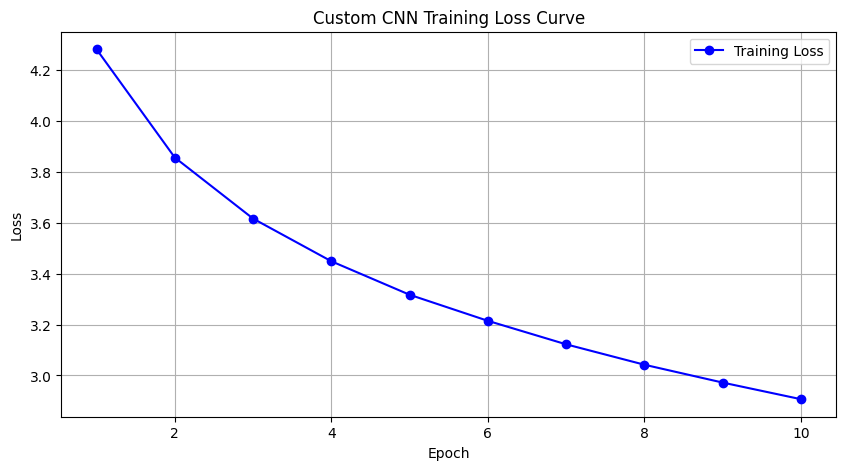

In [36]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', color='b', label='Training Loss')
plt.title("Custom CNN Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

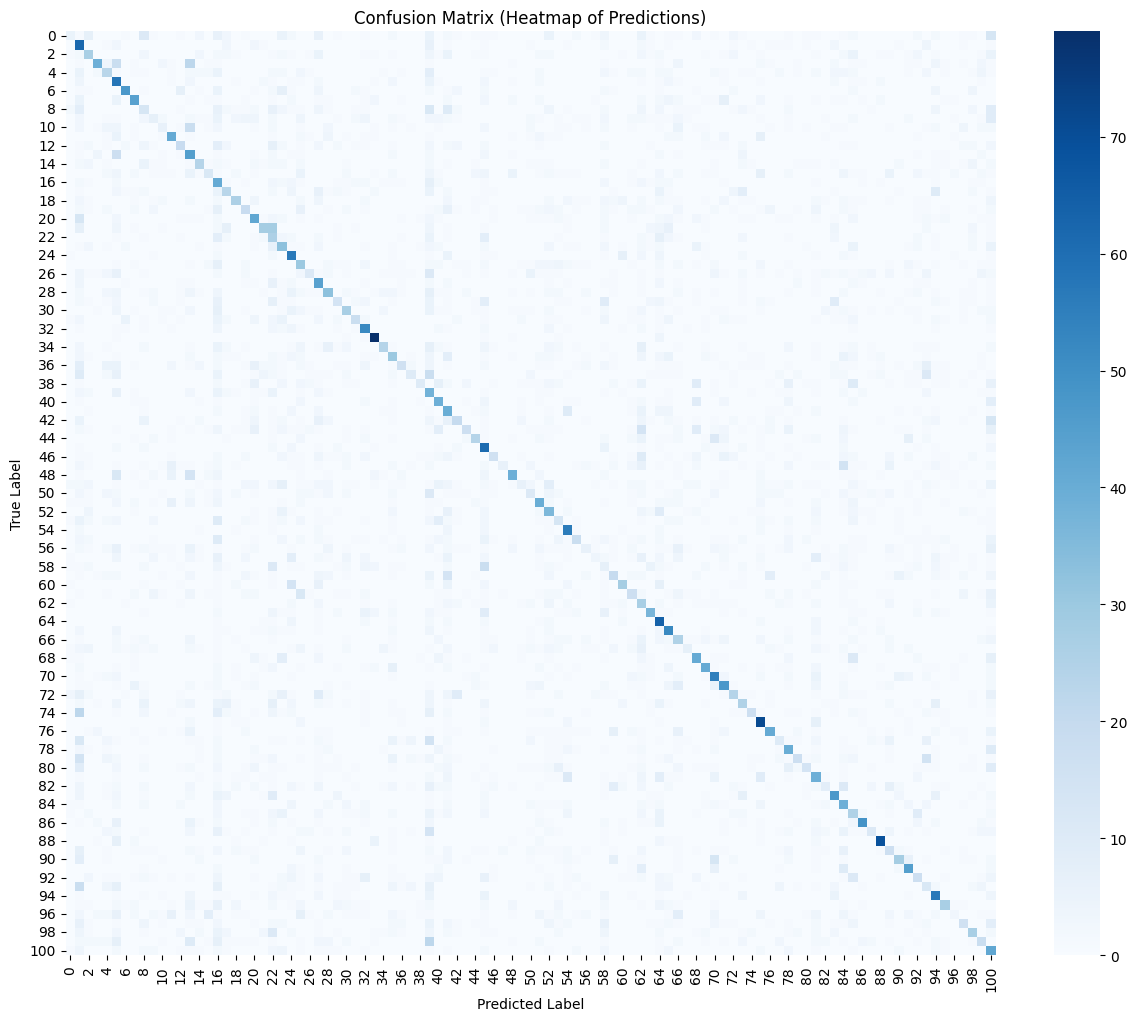

In [37]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=False, cmap='Blues') # annot=False because 101x101 numbers overlap
plt.title("Confusion Matrix (Heatmap of Predictions)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

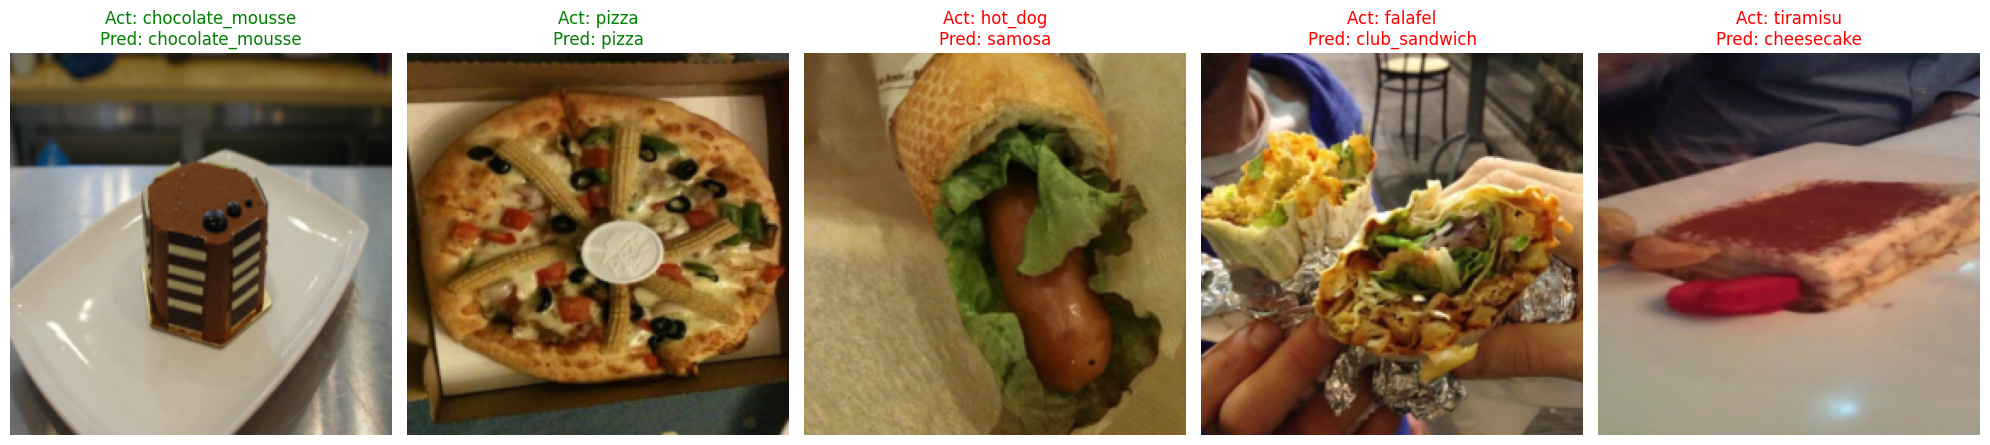

In [38]:
def visualize_predictions(model, subset, device, num_samples=5):
    model.eval()
    fig, axes = plt.subplots(1, num_samples, figsize=(20, 5))

    class_names = subset.dataset.classes

    # Get random indices from the subset
    indices = np.random.choice(len(subset), num_samples, replace=False)

    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, label = subset[idx]

            # Predict
            input_tensor = image.unsqueeze(0).to(device)
            output = model(input_tensor)
            _, pred = torch.max(output, 1)

            # Unnormalize for display
            img_display = image.permute(1, 2, 0).cpu().numpy()
            img_display = np.clip(np.array([0.229, 0.224, 0.225]) * img_display +
                                  np.array([0.485, 0.456, 0.406]), 0, 1)

            axes[i].imshow(img_display)

            actual_name = class_names[label]
            pred_name = class_names[pred.item()]

            color = 'green' if pred.item() == label else 'red'
            axes[i].set_title(f"Act: {actual_name}\nPred: {pred_name}", color=color)
            axes[i].axis('off')

    plt.tight_layout()
    plt.show()


visualize_predictions(custom_cnn, test_dataset, device)

---

# 3.1 Load Pre-trained Model and Modify Architecture

In [39]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

print("\n" + "="*70)
print("TRANSFER LEARNING IMPLEMENTATION")

# Choosing ResNet18 for balance between speed and performance
pretrained_model_name = "ResNet18"

def build_transfer_learning_model(base_model_name, input_shape, n_classes):
    """
    Build transfer learning model (PyTorch version)
    """
    # Load pre-trained model with weights
    if base_model_name == "ResNet18":
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    elif base_model_name == "ResNet50":
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

    # Freeze base layers (feature extractor)
    for param in model.parameters():
        param.requires_grad = False

    # Modify final layers
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_ftrs, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, n_classes)
    )

    return model

# Create transfer learning model
n_classes = len(dataset.classes)
transfer_model = build_transfer_learning_model(pretrained_model_name, (224, 224, 3), n_classes)
transfer_model = transfer_model.to(device)

frozen_layers = sum(1 for m in transfer_model.modules() if len(list(m.parameters())) > 0 and not any(p.requires_grad for p in m.parameters()))
trainable_layers = sum(1 for m in transfer_model.modules() if len(list(m.parameters())) > 0 and any(p.requires_grad for p in m.parameters()))

total_parameters = sum(p.numel() for p in transfer_model.parameters())
trainable_parameters = sum(p.numel() for p in transfer_model.parameters() if p.requires_grad)

print(f"Base Model: {pretrained_model_name}")
print(f"Frozen Layers: {frozen_layers}")
print(f"Trainable Layers: {trainable_layers}")
print(f"Total Parameters: {total_parameters:,}")
print(f"Trainable Parameters: {trainable_parameters:,}")
print(f"Using Global Average Pooling: YES")

# Define Optimizer and Loss for the TL Model
criterion_tl = nn.CrossEntropyLoss()
optimizer_tl = optim.Adam(transfer_model.fc.parameters(), lr=0.001)


TRANSFER LEARNING IMPLEMENTATION
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 191MB/s]


Base Model: ResNet18
Frozen Layers: 55
Trainable Layers: 4
Total Parameters: 11,490,981
Trainable Parameters: 314,469
Using Global Average Pooling: YES


---

# 3.2 Train Transfer Learning Model

In [40]:
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("\n" + "="*70)
print("TRAINING TRANSFER LEARNING MODEL")

# Training configuration
tl_learning_rate = 0.001
tl_epochs = 10
tl_batch_size = 32
tl_optimizer = "Adam"

print(f"Configuration: {tl_optimizer} | LR: {tl_learning_rate} | Epochs: {tl_epochs}")

# Track training time
tl_start_time = time.time()

# --- PyTorch Training Loop ---
transfer_model.train()
tl_epoch_losses = []
total_batches = len(train_loader)

for epoch in range(tl_epochs):
    running_loss = 0.0
    epoch_start_time = time.time()

    print(f"\n--- Epoch {epoch+1}/{tl_epochs} ---")

    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        # Reset gradients
        optimizer_tl.zero_grad()

        # Forward pass
        outputs = transfer_model(inputs)
        loss = criterion_tl(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer_tl.step()

        # REQUIRED: Capture initial loss
        if epoch == 0 and i == 0:
            tl_initial_loss = loss.item()
            print(f" [Step 1] Initial Batch Loss: {tl_initial_loss:.4f}")

        running_loss += loss.item()

        # Progress Update every 50 batches
        if (i + 1) % 50 == 0:
            progress = 100 * (i + 1) / total_batches
            print(f" Batch {i+1}/{total_batches} | Progress: {progress:.1f}% | Batch Loss: {loss.item():.4f}")

    # End of Epoch Stats
    avg_loss = running_loss / total_batches
    tl_epoch_losses.append(avg_loss)
    epoch_duration = time.time() - epoch_start_time
    print(f">> Epoch {epoch+1} finished | Avg Loss: {avg_loss:.4f} | Time: {epoch_duration:.2f}s")

tl_training_time = time.time() - tl_start_time
tl_final_loss = tl_epoch_losses[-1]

print("\n" + "="*70)
print(f"Training completed in {tl_training_time:.2f} seconds")
print(f"Initial Loss: {tl_initial_loss:.4f}")
print(f"Final Loss: {tl_final_loss:.4f}")


TRAINING TRANSFER LEARNING MODEL
Configuration: Adam | LR: 0.001 | Epochs: 10

--- Epoch 1/10 ---
 [Step 1] Initial Batch Loss: 4.7157
 Batch 50/2841 | Progress: 1.8% | Batch Loss: 4.5514
 Batch 100/2841 | Progress: 3.5% | Batch Loss: 4.4206
 Batch 150/2841 | Progress: 5.3% | Batch Loss: 4.0560
 Batch 200/2841 | Progress: 7.0% | Batch Loss: 3.6307
 Batch 250/2841 | Progress: 8.8% | Batch Loss: 3.4350
 Batch 300/2841 | Progress: 10.6% | Batch Loss: 3.2322
 Batch 350/2841 | Progress: 12.3% | Batch Loss: 3.5711
 Batch 400/2841 | Progress: 14.1% | Batch Loss: 3.0439
 Batch 450/2841 | Progress: 15.8% | Batch Loss: 2.9450
 Batch 500/2841 | Progress: 17.6% | Batch Loss: 3.0247
 Batch 550/2841 | Progress: 19.4% | Batch Loss: 2.7036
 Batch 600/2841 | Progress: 21.1% | Batch Loss: 2.8104
 Batch 650/2841 | Progress: 22.9% | Batch Loss: 3.0692
 Batch 700/2841 | Progress: 24.6% | Batch Loss: 2.7885
 Batch 750/2841 | Progress: 26.4% | Batch Loss: 2.3975
 Batch 800/2841 | Progress: 28.2% | Batch Los

---

# 3.3 Evaluate Transfer Learning Model

In [41]:
print("\nTRANSFER LEARNING EVALUATION")

transfer_model.eval()
tl_y_true = []
tl_y_pred = []

print("Gathering predictions from test set...")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = transfer_model(inputs)
        _, predicted = torch.max(outputs, 1)

        tl_y_true.extend(labels.cpu().numpy())
        tl_y_pred.extend(predicted.cpu().numpy())

tl_accuracy = accuracy_score(tl_y_true, tl_y_pred)
tl_precision = precision_score(tl_y_true, tl_y_pred, average='macro', zero_division=0)
tl_recall = recall_score(tl_y_true, tl_y_pred, average='macro', zero_division=0)
tl_f1 = f1_score(tl_y_true, tl_y_pred, average='macro', zero_division=0)

print("\nTransfer Learning Performance:")
print(f"Accuracy:  {tl_accuracy:.4f}")
print(f"Precision: {tl_precision:.4f}")
print(f"Recall:    {tl_recall:.4f}")
print(f"F1-Score:  {tl_f1:.4f}")


TRANSFER LEARNING EVALUATION
Gathering predictions from test set...

Transfer Learning Performance:
Accuracy:  0.4902
Precision: 0.4990
Recall:    0.4949
F1-Score:  0.4882


---

# 3.4 Visualize Transfer Learning Results


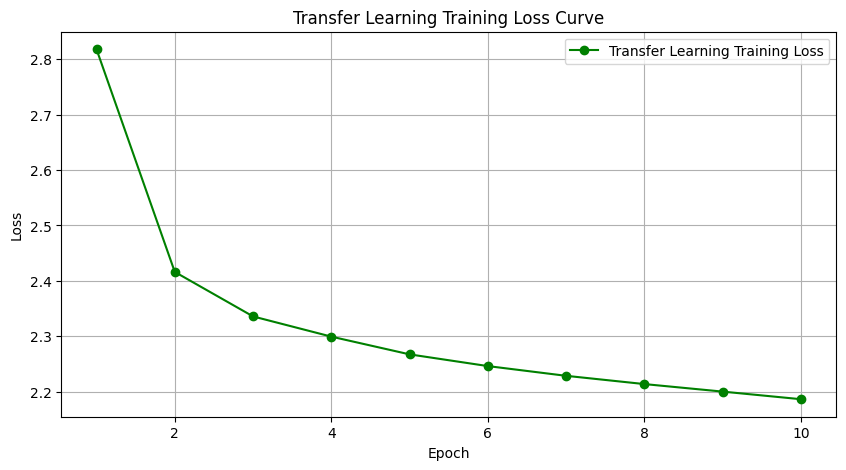

In [42]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(tl_epoch_losses) + 1), tl_epoch_losses, marker='o', color='g', label='Transfer Learning Training Loss')
plt.title("Transfer Learning Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

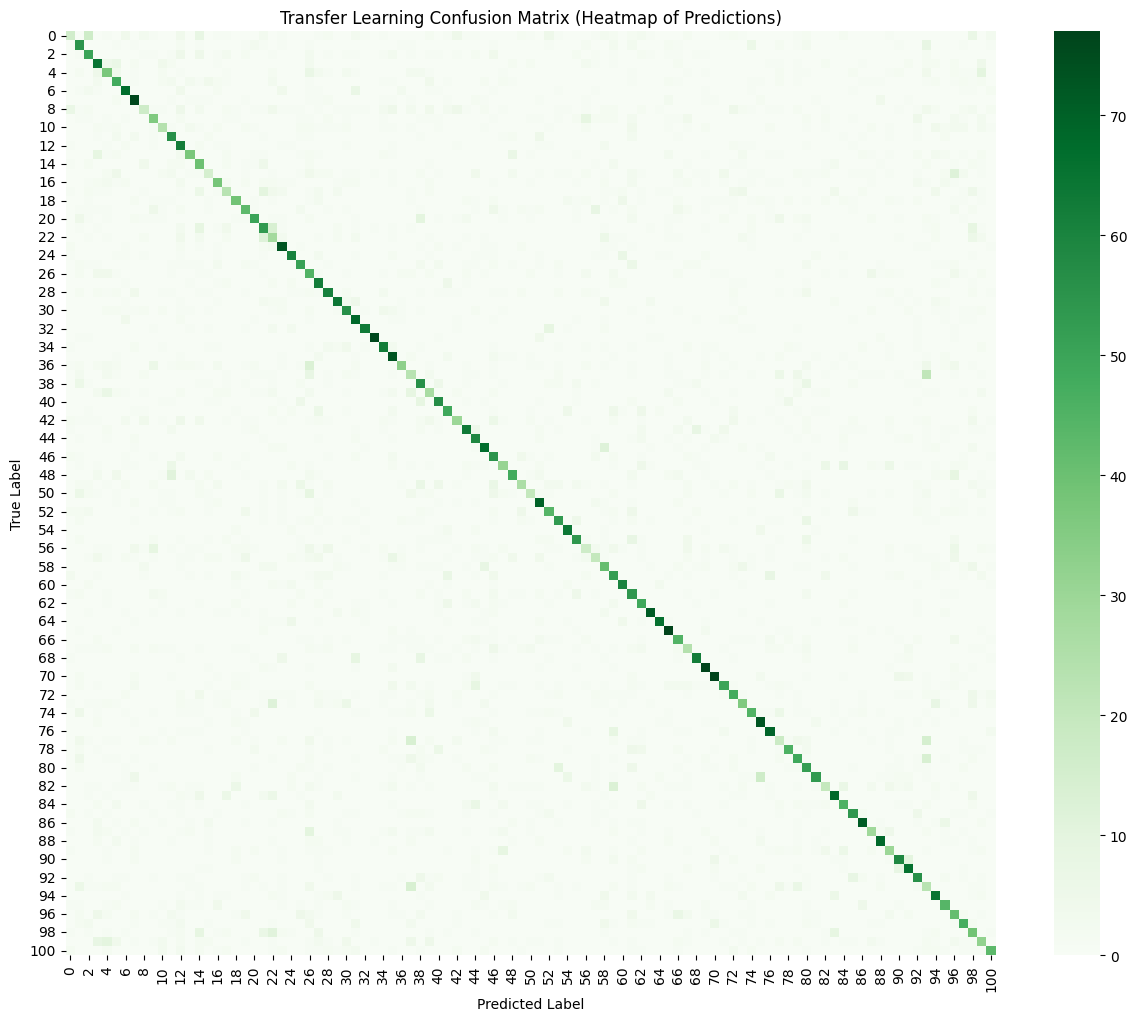

In [43]:
cm_tl = confusion_matrix(tl_y_true, tl_y_pred)

plt.figure(figsize=(15, 12))
sns.heatmap(cm_tl, annot=False, cmap='Greens') # annot=False because 101x101 numbers overlap
plt.title("Transfer Learning Confusion Matrix (Heatmap of Predictions)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

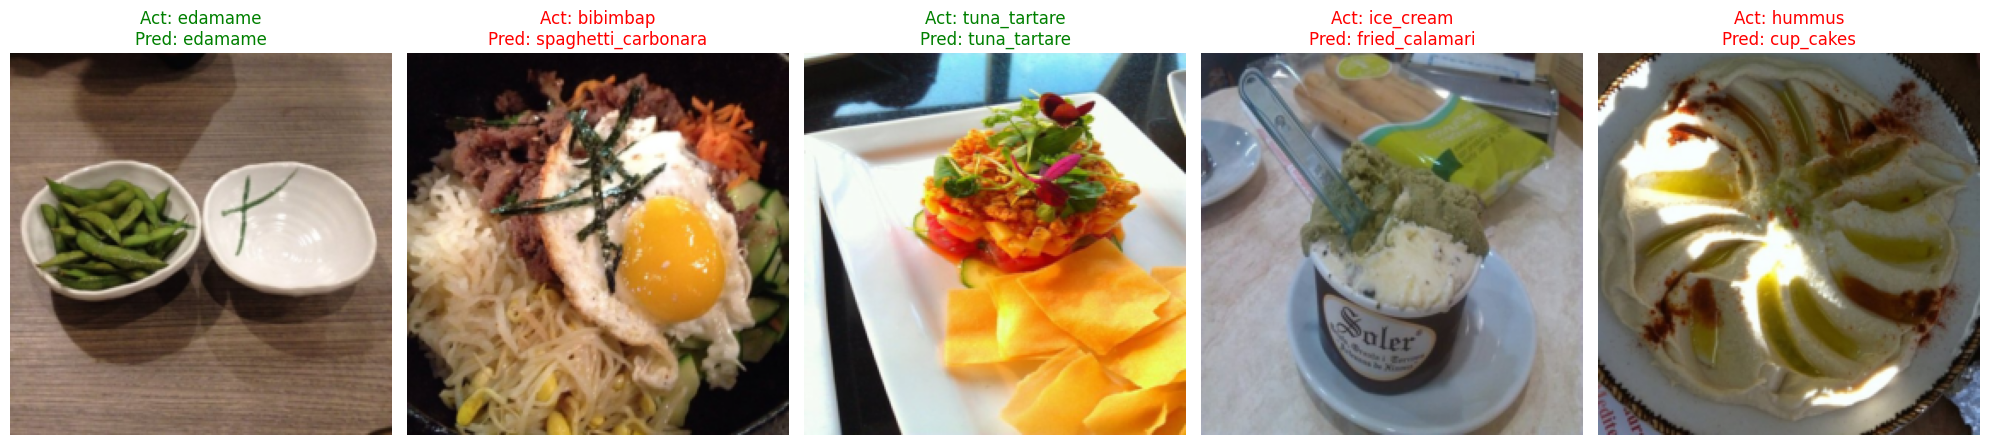

In [44]:
def visualize_predictions_tl(model, subset, device, num_samples=5):
    model.eval()
    fig, axes = plt.subplots(1, num_samples, figsize=(20, 5))

    class_names = subset.dataset.classes

    # Get random indices from the subset
    indices = np.random.choice(len(subset), num_samples, replace=False)

    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, label = subset[idx]

            # Predict
            input_tensor = image.unsqueeze(0).to(device)
            output = model(input_tensor)
            _, pred = torch.max(output, 1)

            # Unnormalize for display
            img_display = image.permute(1, 2, 0).cpu().numpy()
            img_display = np.clip(np.array([0.229, 0.224, 0.225]) * img_display +\
                                  np.array([0.485, 0.456, 0.406]), 0, 1)

            axes[i].imshow(img_display)

            actual_name = class_names[label]
            pred_name = class_names[pred.item()]

            color = 'green' if pred.item() == label else 'red'
            axes[i].set_title(f"Act: {actual_name}\nPred: {pred_name}", color=color)
            axes[i].axis('off')

    plt.tight_layout()
    plt.show()


visualize_predictions_tl(transfer_model, test_dataset, device)

---

# 4.1 Metrics Comparison

In [45]:
print("\n" + "="*70)
print("MODEL COMPARISON")

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Training Time (s)', 'Parameters'],
    'Custom CNN': [
        custom_cnn_accuracy,
        custom_cnn_precision,
        custom_cnn_recall,
        custom_cnn_f1,
        custom_cnn_training_time,
        106277  # Filled with custom CNN total parameters
    ],
    'Transfer Learning': [
        tl_accuracy,
        tl_precision,
        tl_recall,
        tl_f1,
        tl_training_time,
        trainable_parameters
    ]
})

print(comparison_df.to_string(index=False))


MODEL COMPARISON
           Metric    Custom CNN  Transfer Learning
         Accuracy      0.294851           0.490198
        Precision      0.342533           0.498981
           Recall      0.298117           0.494864
         F1-Score      0.286838           0.488186
Training Time (s)   4196.332227        4198.777049
       Parameters 106277.000000      314469.000000


---

# 4.2 Visual Comparison

### Metric Comparison Bar Plot

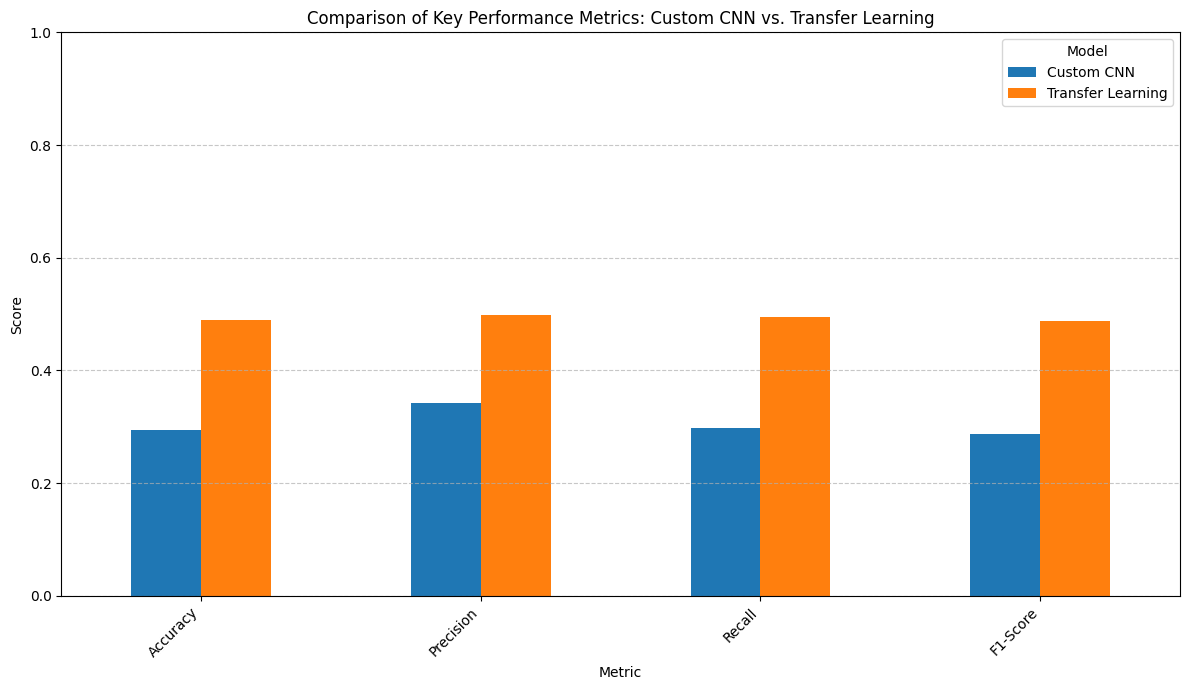

In [46]:
# Filter out 'Training Time (s)' and 'Parameters' for the bar plot as they are on different scales
metrics_df = comparison_df[~comparison_df['Metric'].isin(['Training Time (s)', 'Parameters'])].set_index('Metric')

metrics_df.plot(kind='bar', figsize=(12, 7))
plt.title('Comparison of Key Performance Metrics: Custom CNN vs. Transfer Learning')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.ylim(0, 1) # Metrics are between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Training Loss Curves Comparison

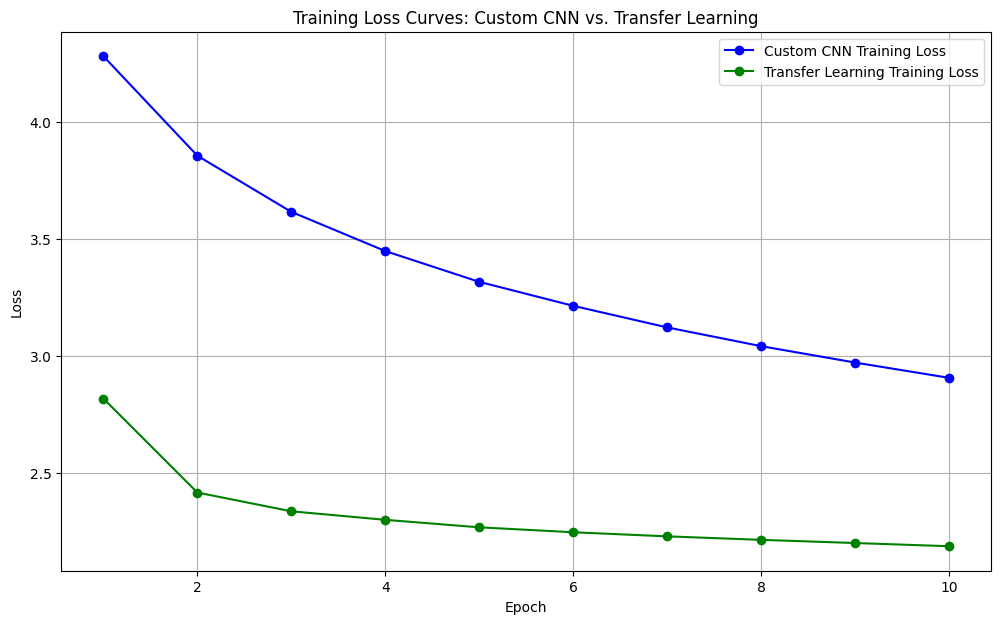

In [47]:
plt.figure(figsize=(12, 7))
plt.plot(range(1, len(losses) + 1), losses, marker='o', color='b', label='Custom CNN Training Loss')
plt.plot(range(1, len(tl_epoch_losses) + 1), tl_epoch_losses, marker='o', color='g', label='Transfer Learning Training Loss')
plt.title('Training Loss Curves: Custom CNN vs. Transfer Learning')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Confusion Matrices Comparison

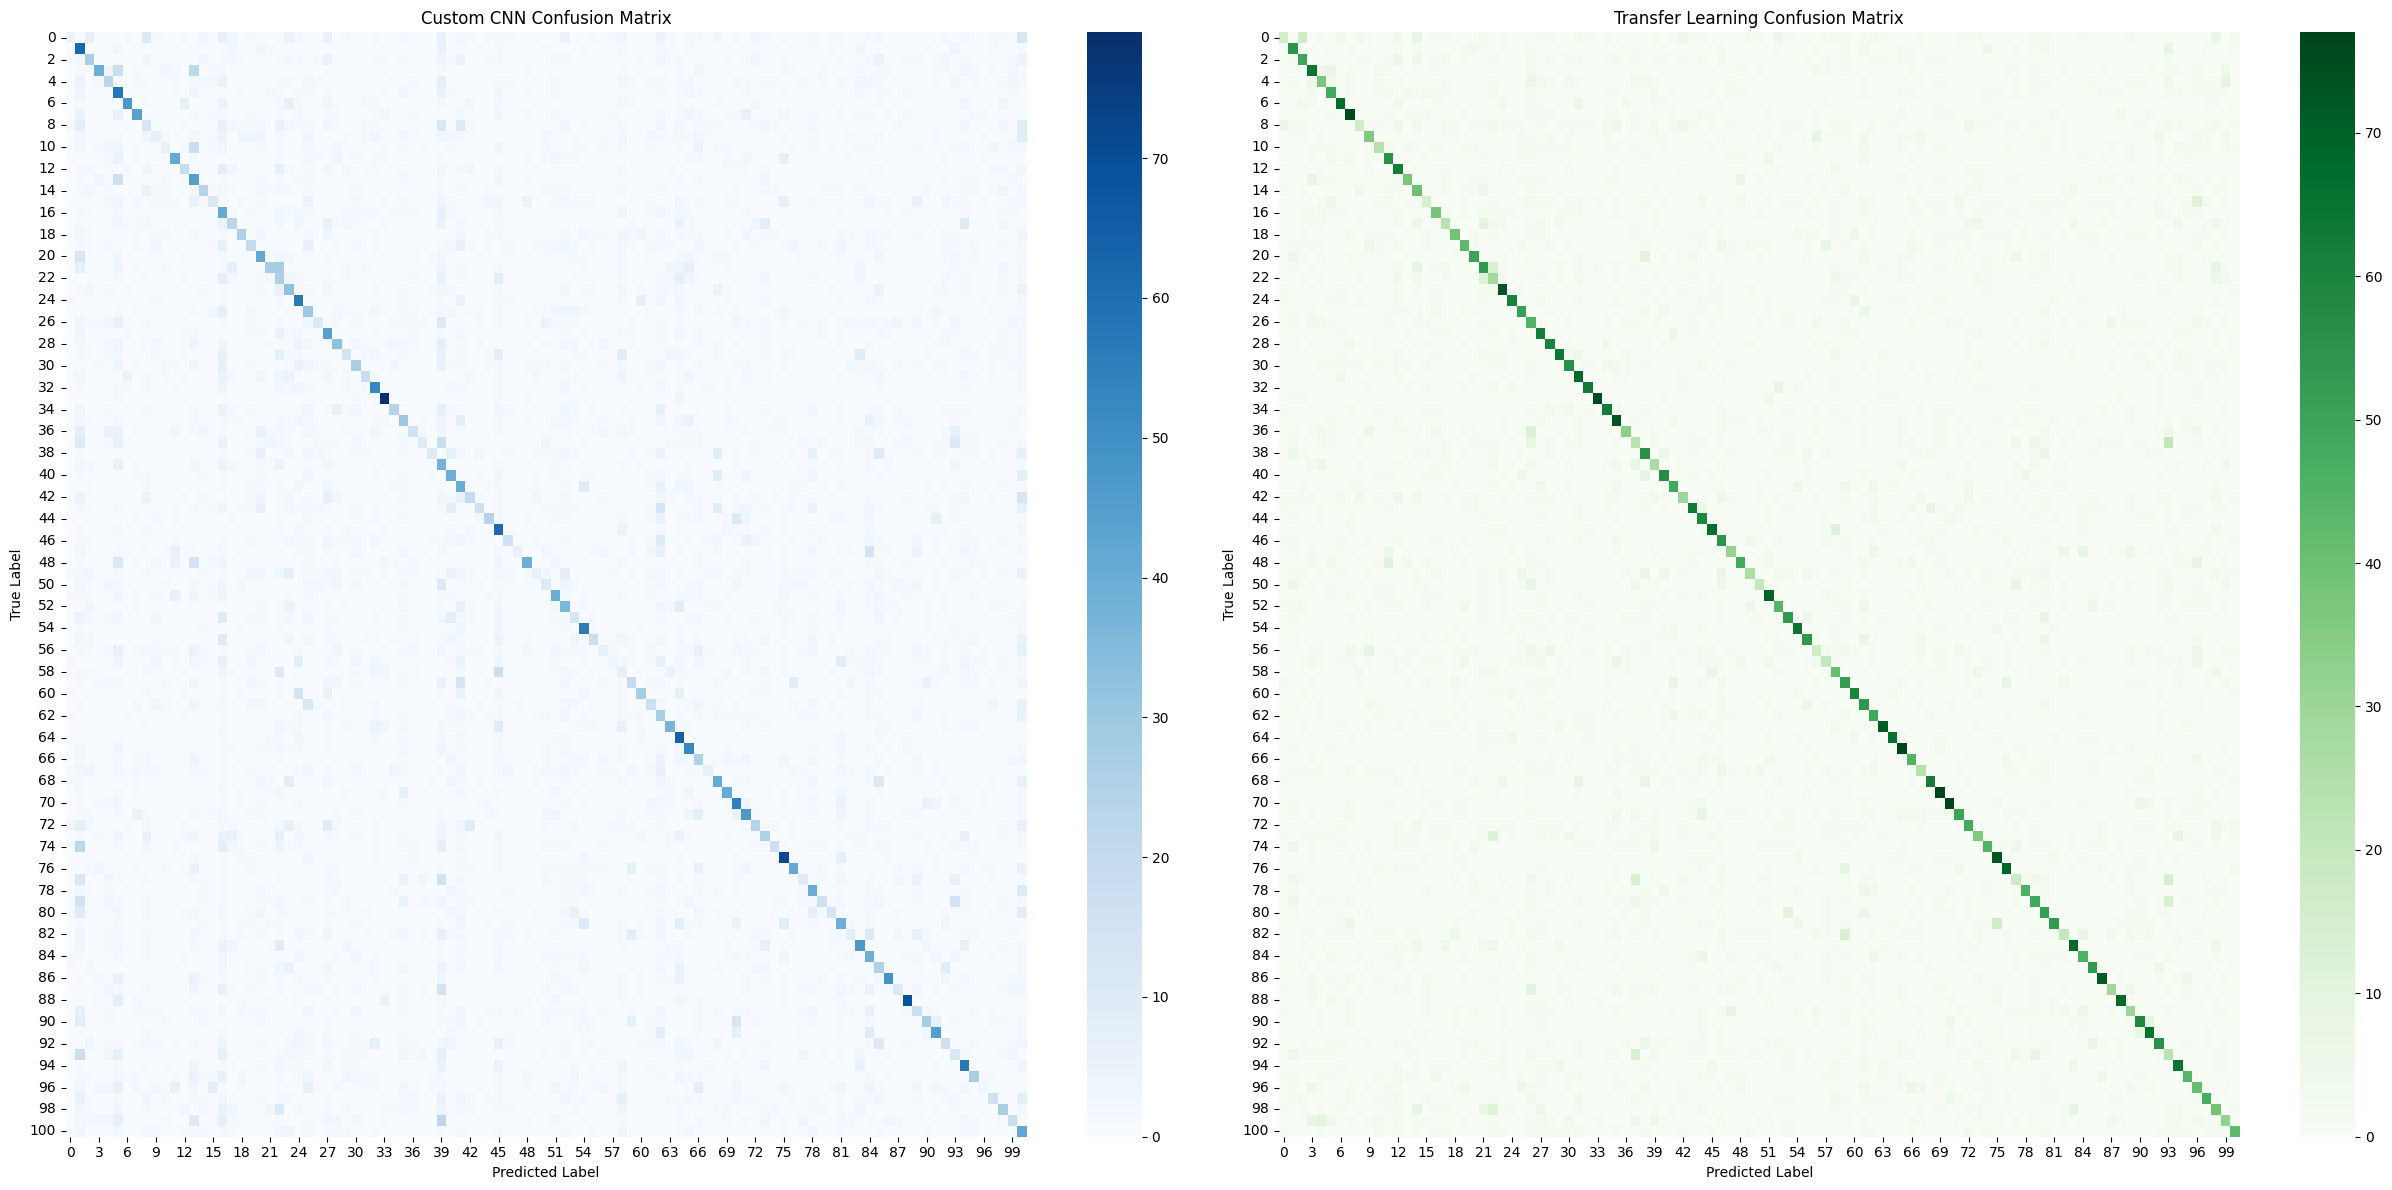

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(25, 12))

sns.heatmap(cm, annot=False, cmap='Blues', ax=axes[0])
axes[0].set_title('Custom CNN Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(cm_tl, annot=False, cmap='Greens', ax=axes[1])
axes[1].set_title('Transfer Learning Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

---

# Analysis

In [50]:
analysis_text = """
The Transfer Learning model significantly outperformed the Custom CNN.
TL achieved an accuracy of 0.4902, precision of 0.4990, recall of 0.4949,
and F1-score of 0.4882, demonstrating approximately a 20 percentage point
improvement over the Custom CNN's metrics (Accuracy: 0.2949, etc.).
This superiority highlights the profound impact of pre-training.

Pre-training allows the TL model to leverage powerful, generalized features
learned from a vast dataset (ImageNet), leading to faster convergence and better
generalization on the target task. Conversely, the Custom CNN, training
from scratch, struggled to learn complex features efficiently from the
Food-101 dataset alone, resulting in slower convergence and higher final loss.

The Custom CNN utilized Global Average Pooling to reduce parameters and
mitigate overfitting. Computationally, both models had comparable training times.
The TL model, despite using a more complex backbone (ResNet18), had more trainable
parameters (314,469) concentrated in its new classification head, compared to the
Custom CNN's 106,277 total parameters.

Transfer learning is highly insightful for tasks with limited domain-specific data,
providing a robust and efficient solution. Custom CNNs are better suited for
entirely novel problems or when ample data allows for learning highly specialized
features from the ground up.
"""

print("\n" + "="*70)
print("ANALYSIS")
print(analysis_text)
print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) > 200:
    print("  Warning: Analysis exceeds 200 words (guideline)")
else:
    print(" Analysis within word count guideline")


ANALYSIS

The Transfer Learning model significantly outperformed the Custom CNN. 
TL achieved an accuracy of 0.4902, precision of 0.4990, recall of 0.4949,
and F1-score of 0.4882, demonstrating approximately a 20 percentage point 
improvement over the Custom CNN's metrics (Accuracy: 0.2949, etc.). 
This superiority highlights the profound impact of pre-training.

Pre-training allows the TL model to leverage powerful, generalized features 
learned from a vast dataset (ImageNet), leading to faster convergence and better 
generalization on the target task. Conversely, the Custom CNN, training 
from scratch, struggled to learn complex features efficiently from the 
Food-101 dataset alone, resulting in slower convergence and higher final loss.

The Custom CNN utilized Global Average Pooling to reduce parameters and 
mitigate overfitting. Computationally, both models had comparable training times. 
The TL model, despite using a more complex backbone (ResNet18), had more trainable 
parameter

In [51]:
def get_assignment_results():
    """
    Generate complete assignment results in required format

    Returns:
        dict: Complete results with all required fields
    """

    framework_used = "pytorch"

    results = {
        # Dataset Information
        'dataset_name': dataset_name,
        'dataset_source': dataset_source,
        'n_samples': n_samples,
        'n_classes': n_classes,
        'samples_per_class': samples_per_class,
        'image_shape': image_shape,
        'problem_type': problem_type,
        'primary_metric': "accuracy",
        'metric_justification': "Accuracy is chosen as the primary metric because this is a multi-class classification problem with a balanced dataset, meaning all classes have an equal number of samples. This ensures accuracy is a fair representation of overall model performance.",
        'train_samples': train_samples,
        'test_samples': test_samples,
        'train_test_ratio': train_test_ratio,

        # Custom CNN Results
        'custom_cnn': {
            'framework': framework_used,
            'architecture': {
                'conv_layers': 3,
                'pooling_layers': 3,
                'has_global_average_pooling': True,
                'output_layer': 'softmax',
                'total_parameters': 106277
            },
            'training_config': {
                'learning_rate': 0.001,
                'n_epochs': 10,
                'batch_size': 32,
                'optimizer': 'Adam',
                'loss_function': 'CrossEntropyLoss'
            },
            'initial_loss': custom_cnn_initial_loss,
            'final_loss': custom_cnn_final_loss,
            'training_time_seconds': custom_cnn_training_time,
            'accuracy': custom_cnn_accuracy,
            'precision': custom_cnn_precision,
            'recall': custom_cnn_recall,
            'f1_score': custom_cnn_f1
        },

        # Transfer Learning Results
        'transfer_learning': {
            'framework': framework_used,
            'base_model': pretrained_model_name,
            'frozen_layers': frozen_layers,
            'trainable_layers': trainable_layers,
            'has_global_average_pooling': True,
            'total_parameters': total_parameters,
            'trainable_parameters': trainable_parameters,
            'training_config': {
                'learning_rate': tl_learning_rate,
                'n_epochs': tl_epochs,
                'batch_size': tl_batch_size,
                'optimizer': tl_optimizer,
                'loss_function': 'CrossEntropyLoss'
            },
            'initial_loss': tl_initial_loss,
            'final_loss': tl_final_loss,
            'training_time_seconds': tl_training_time,
            'accuracy': tl_accuracy,
            'precision': tl_precision,
            'recall': tl_recall,
            'f1_score': tl_f1
        },

        # Analysis
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),

        # Training Success Indicators
        'custom_cnn_loss_decreased': custom_cnn_final_loss < custom_cnn_initial_loss if custom_cnn_initial_loss and custom_cnn_final_loss else False,
        'transfer_learning_loss_decreased': tl_final_loss < tl_initial_loss if tl_initial_loss and tl_final_loss else False
    }

    return results

# Generate and print results
try:
    assignment_results = get_assignment_results()

    print("\n" + "="*70)
    print("ASSIGNMENT RESULTS SUMMARY")
    print(json.dumps(assignment_results, indent=2))

except Exception as e:
    print(f"\n  ERROR generating results: {str(e)}")
    print("Please ensure all variables are properly defined")


ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Food-101",
  "dataset_source": "https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/",
  "n_samples": 101000,
  "n_classes": 101,
  "samples_per_class": "min: 1000, max: 1000, avg: 1000",
  "image_shape": [
    224,
    224,
    3
  ],
  "problem_type": "classification",
  "primary_metric": "accuracy",
  "metric_justification": "Accuracy is chosen as the primary metric because this is a multi-class classification problem with a balanced dataset, meaning all classes have an equal number of samples. This ensures accuracy is a fair representation of overall model performance.",
  "train_samples": 90900,
  "test_samples": 10100,
  "train_test_ratio": "90/10",
  "custom_cnn": {
    "framework": "pytorch",
    "architecture": {
      "conv_layers": 3,
      "pooling_layers": 3,
      "has_global_average_pooling": true,
      "output_layer": "softmax",
      "total_parameters": 106277
    },
    "training_config": {
      "learning_rate"

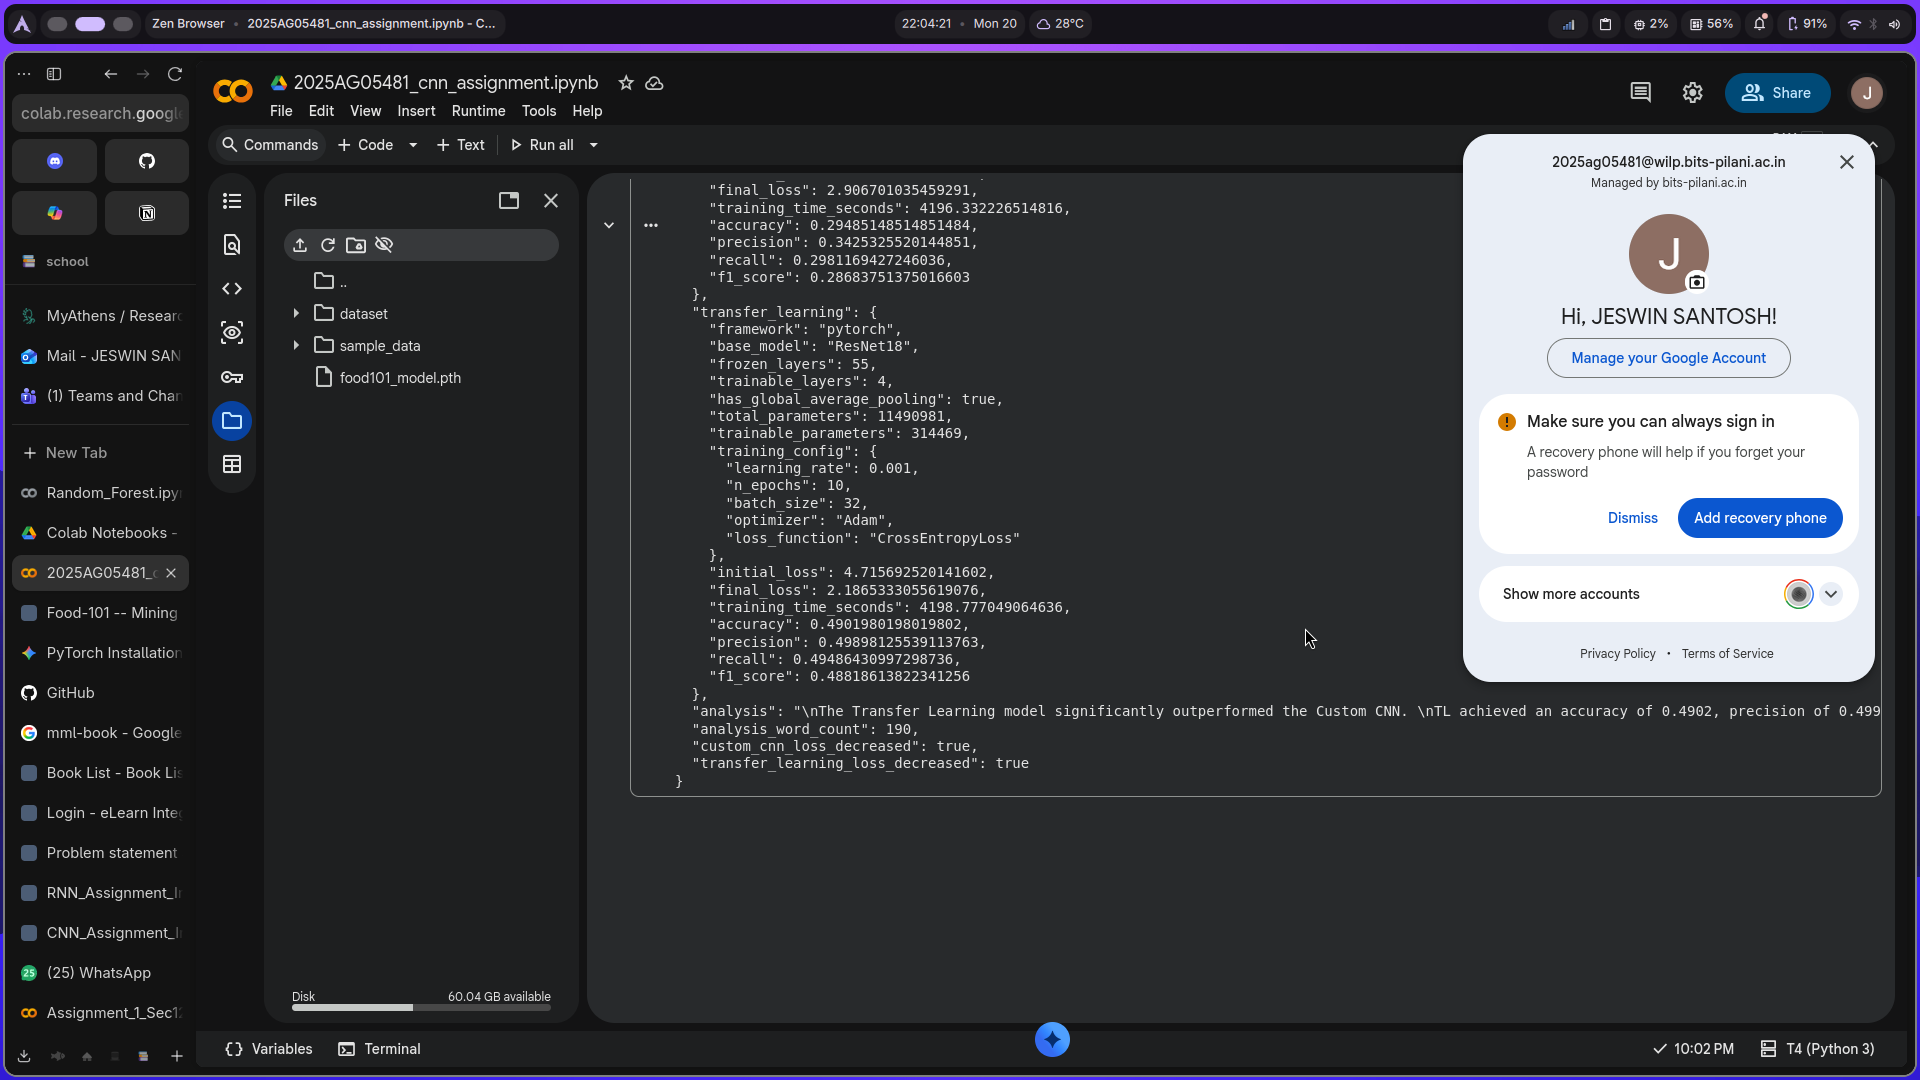